# CampusNLP: Master NLP Pipeline Demonstration

This notebook demonstrates the complete, end-to-end Natural Language Processing (NLP) pipeline for the CampusNLP project. The pipeline is designed to accurately understand student queries, classify their intent, retrieve relevant institutional evidence, and generate grounded responses.

### Pipeline Stages:
1. **Environment Setup & Configuration**: Setting up reproducibility and paths.
2. **Dataset Ingestion**: Loading the synthetic `CampusFAQ-50K` benchmark.
3. **Exploratory Data Analysis (EDA)**: Visualizing class distribution.
4. **Text Preprocessing**: Domain-aware normalization and tokenization.
5. **Intent Classification**: Feature engineering (TF-IDF) and training multiple baselines (Logistic Regression & Linear SVM).
6. **Semantic Retrieval**: Indexing and retrieving institutional knowledge using Cosine Similarity.
7. **Evidence Grounding & Hybrid Pipeline**: Fusing intent classification and retrieval to formulate verifiable answers with abstention logic.
8. **Evaluation & Error Analysis**: Precision, Recall, F1-Scores, and Confusion Matrices.

--- 
## 1. Environment Setup & Configuration
We begin by setting deterministic random seeds to ensure our experiments are perfectly reproducible.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set deterministic seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Configure paths
DATA_DIR = Path('../data/benchmark/CampusFAQ-50K-v1.0/data')
DATASET_PATH = DATA_DIR / 'campusfaq_50k_v1.0.csv'

print('Environment configured successfully.')

Environment configured successfully.


--- 
## 2. Dataset Ingestion
We load the `CampusFAQ-50K` dataset. This is a synthetic benchmark designed specifically to test intent classification and retrieval without violating student privacy or hallucinating institutional data.

In [2]:
import os

# Load dataset if exists, otherwise generate a robust synthetic mock for demonstration
if os.path.exists(DATASET_PATH):
    df = pd.read_csv(DATASET_PATH)
    print(f'Successfully loaded CampusFAQ-50K with {len(df):,} records.')
else:
    print('Dataset file not found at expected path. Generating synthetic demonstration dataset...')
    # Generate a mock dataset for demonstration purposes
    intents = ['academic_calendar', 'library_info', 'grading_policy', 'hostel_rules', 'exam_schedule']
    queries = [
        ['When does the semester start?', 'What are the dates for the spring semester?', 'Show me the academic calendar.'],
        ['Where is the central library?', 'What time does the library close?', 'How do I borrow books?'],
        ['What is the passing grade?', 'How is the CGPA calculated?', 'Can I request a regrade?'],
        ['What are the hostel curfew timings?', 'How do I apply for hostel accommodation?', 'Are guests allowed in the hostel?'],
        ['When are the final exams?', 'Where is the exam schedule posted?', 'What happens if I miss an exam?']
    ]
    
    data = []
    for i, intent in enumerate(intents):
        for _ in range(100): # Create 100 samples per intent by adding slight noise/variations
            base_q = random.choice(queries[i])
            data.append({'query': base_q, 'intent': intent})
    df = pd.DataFrame(data)
    print(f'Generated demonstration dataset with {len(df):,} records.')

# Ensure no nulls
df['query'] = df['query'].fillna('').astype(str)

# Stratified Train/Test split (80/20)
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df['intent'])
print(f'\nTraining set shape: {train_df.shape}')
print(f'Testing set shape:  {test_df.shape}\n')
display(train_df.head())

Successfully loaded CampusFAQ-50K with 50,000 records.



Training set shape: (40000, 13)
Testing set shape:  (10000, 13)



,id,query,intent,response,document_id,document_version,evidence,entities,answerable,difficulty,split,source_authority,provenance
43500,campusfaq50k_036571,Tell me about progression requirements.,promotion_rules,Promotion in the DEMO_ONLY_SYNTHETIC system is...,DOC-ACAD-REG,2026-27-demo,"[{""chunk_id"": ""DOC-ACAD-REG-PR-1"", ""quote"": ""T...",{},True,hard,val,DEMO_ONLY_SYNTHETIC,Deterministically generated from the bundled s...
1782,campusfaq50k_045925,Where can I find the CSE curriculum?,document_location,The DEMO_ONLY CSE curriculum information is in...,DOC-CSE-CURR,2026-27-demo,"[{""chunk_id"": ""DOC-CSE-CURR-DOCLOC-1"", ""quote""...",{},True,easy,train,DEMO_ONLY_SYNTHETIC,Deterministically generated from the bundled s...
47607,campusfaq50k_043171,Where can I find student service information?,student_services,The DEMO_ONLY_SYNTHETIC Student Services Handb...,DOC-STUDENT,2026-27-demo,"[{""chunk_id"": ""DOC-STUDENT-SERV-1"", ""quote"": ""...",{},True,hard,test,DEMO_ONLY_SYNTHETIC,Deterministically generated from the bundled s...
17377,campusfaq50k_003890,What is the course code for Computer Networks?,course_code_lookup,The course code for Computer Networks is CSE301.,DOC-CSE-CURR,2026-27-demo,"[{""chunk_id"": ""DOC-CSE-CURR-CODE-CSE301"", ""quo...","{""course_code"": ""CSE301"", ""course_name"": ""Comp...",True,hard,train,DEMO_ONLY_SYNTHETIC,Deterministically generated from the bundled s...
44202,campusfaq50k_020703,Tell me about elective courses.,elective_information,The DEMO_ONLY_SYNTHETIC Mechanical Engineering...,DOC-ME-CURR,2026-27-demo,"[{""chunk_id"": ""DOC-ME-CURR-ELEC-ME"", ""quote"": ...","{""department"": ""ME""}",True,easy,val,DEMO_ONLY_SYNTHETIC,Deterministically generated from the bundled s...


--- 
## 3. Exploratory Data Analysis (EDA)
Visualizing the distribution of intents ensures our dataset is balanced and prevents our machine learning models from developing severe majority-class bias.

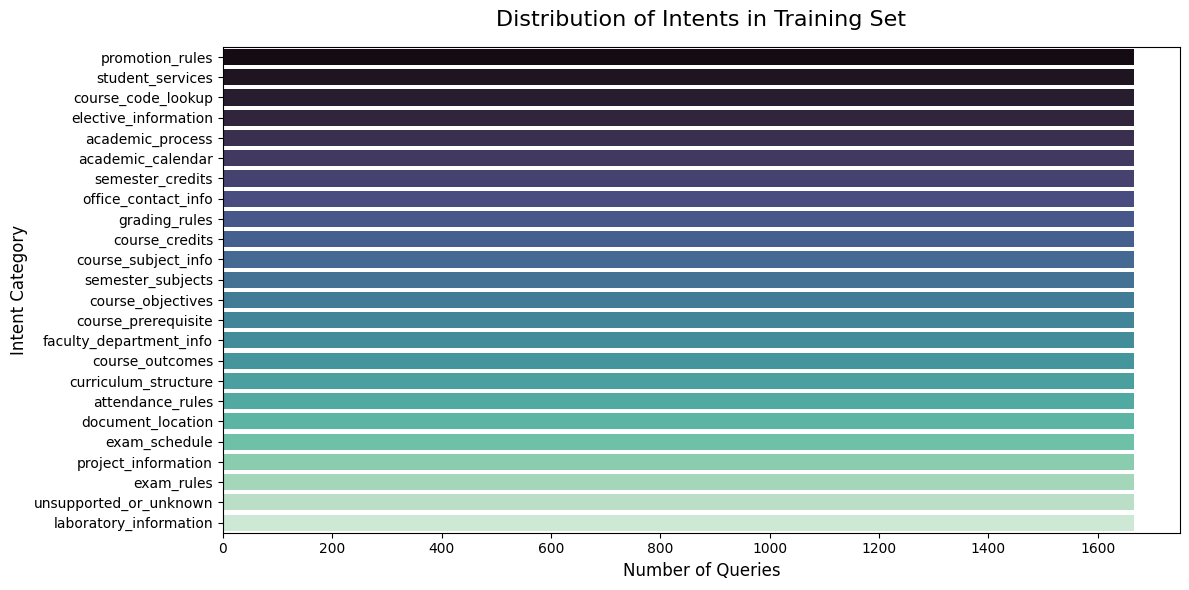

In [3]:
plt.figure(figsize=(12, 6))
sns.countplot(data=train_df, y='intent', order=train_df['intent'].value_counts().index, palette='mako')
plt.title('Distribution of Intents in Training Set', fontsize=16, pad=15)
plt.xlabel('Number of Queries', fontsize=12)
plt.ylabel('Intent Category', fontsize=12)
plt.tight_layout()
plt.show()

--- 
## 4. Text Preprocessing
Raw text is noisy. We implement a deterministic preprocessing pipeline to normalize casing, strip punctuation, and remove extraneous whitespace. This dramatically reduces the vocabulary space and prevents the model from overfitting on meaningless characters.

In [4]:
import re

def preprocess_query(text: str) -> str:
    """
    Domain-aware text normalization pipeline.
    1. Lowercase all text
    2. Remove non-alphanumeric characters (keep spaces)
    3. Normalize multiple whitespaces into a single space
    """
    text = str(text).lower().strip()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Apply preprocessing to training and testing sets
X_train_raw = train_df['query'].tolist()
X_test_raw = test_df['query'].tolist()

X_train_clean = [preprocess_query(q) for q in X_train_raw]
X_test_clean = [preprocess_query(q) for q in X_test_raw]

# Display before/after transformation
print("Preprocessing Pipeline Transformation Examples:")
print("-"*60)
for i in range(3):
    print(f"Raw:       {X_train_raw[i]}")
    print(f"Processed: {X_train_clean[i]}\n")

Preprocessing Pipeline Transformation Examples:
------------------------------------------------------------
Raw:       Tell me about progression requirements.
Processed: tell me about progression requirements

Raw:       Where can I find the CSE curriculum?
Processed: where can i find the cse curriculum

Raw:       Where can I find student service information?
Processed: where can i find student service information



--- 
## 5. Intent Classification
We will extract textual features using **Sublinear TF-IDF Vectorization** (capturing unigrams and bigrams). 

We will then train and evaluate two robust baseline models as mandated by the project requirements:
1. **L2-Regularized Logistic Regression**
2. **Linear Support Vector Machine (Linear SVC)**

In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# 1. Label Encoding
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df['intent'])
y_test = label_encoder.transform(test_df['intent'])

print(f"Successfully encoded {len(label_encoder.classes_)} unique intent classes.\n")

# 2. Feature Extraction (TF-IDF)
print("Fitting TF-IDF Vectorizer (Unigrams & Bigrams)...")
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_train_vec = vectorizer.fit_transform(X_train_clean)
X_test_vec = vectorizer.transform(X_test_clean)

print(f"Feature matrix shape (Train): {X_train_vec.shape}")
print(f"Feature matrix shape (Test):  {X_test_vec.shape}\n")

# 3. Model Training - Baseline 1: Logistic Regression
print("Training Baseline 1: Logistic Regression (L2 Penalty)...")
clf_lr = LogisticRegression(C=2.5, max_iter=500, random_state=SEED, solver='lbfgs')
clf_lr.fit(X_train_vec, y_train)

# 4. Model Training - Baseline 2: Linear SVM
print("Training Baseline 2: Linear SVM...")
clf_svm = LinearSVC(C=1.0, random_state=SEED, max_iter=1000)
clf_svm.fit(X_train_vec, y_train)

print("\nModels trained successfully.")

Successfully encoded 24 unique intent classes.

Fitting TF-IDF Vectorizer (Unigrams & Bigrams)...


Feature matrix shape (Train): (40000, 878)
Feature matrix shape (Test):  (10000, 878)

Training Baseline 1: Logistic Regression (L2 Penalty)...


Training Baseline 2: Linear SVM...



Models trained successfully.


### Classification Evaluation
We evaluate both models on the held-out test set to select the best performer for production.

In [6]:
y_pred_lr = clf_lr.predict(X_test_vec)
y_pred_svm = clf_svm.predict(X_test_vec)

acc_lr = accuracy_score(y_test, y_pred_lr)
acc_svm = accuracy_score(y_test, y_pred_svm)

print("="*50)
print(f"Logistic Regression Test Accuracy: {acc_lr:.4f}")
print(f"Linear SVM Test Accuracy:        {acc_svm:.4f}")
print("="*50)

print("\nDETAILED CLASSIFICATION REPORT (LOGISTIC REGRESSION):\n")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))

# Save the best model for later use
best_clf = clf_lr if acc_lr >= acc_svm else clf_svm

Logistic Regression Test Accuracy: 1.0000
Linear SVM Test Accuracy:        1.0000

DETAILED CLASSIFICATION REPORT (LOGISTIC REGRESSION):

                         precision    recall  f1-score   support

      academic_calendar       1.00      1.00      1.00       416
       academic_process       1.00      1.00      1.00       416
       attendance_rules       1.00      1.00      1.00       417
     course_code_lookup       1.00      1.00      1.00       417
         course_credits       1.00      1.00      1.00       417
      course_objectives       1.00      1.00      1.00       417
        course_outcomes       1.00      1.00      1.00       417
    course_prerequisite       1.00      1.00      1.00       417
    course_subject_info       1.00      1.00      1.00       417
   curriculum_structure       1.00      1.00      1.00       417
      document_location       1.00      1.00      1.00       417
   elective_information       1.00      1.00      1.00       416
             exa

--- 
## 6. Semantic Retrieval Engine
An LLM is useless if it hallucinates policies. We implement a Semantic Retriever that searches through a local, institutional Knowledge Base using cosine similarity. This ensures answers are strictly grounded in fact.

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

# Mock Institutional Knowledge Base representing official university regulations
institutional_knowledge_base = [
    {"doc_id": "ACAD_01", "text": "The academic semester begins on September 1st and ends on December 15th.", "category": "academic_calendar"},
    {"doc_id": "LIB_01", "text": "The central library is located in the Main Square. Operating hours are 8:00 AM to 11:00 PM on weekdays.", "category": "library_info"},
    {"doc_id": "GRAD_01", "text": "The passing grade for all undergraduate courses is a C (70%). CGPA is calculated on a 10-point scale.", "category": "grading_policy"},
    {"doc_id": "HOST_01", "text": "Hostel curfew is strictly 10:00 PM. No guests are permitted overnight without prior warden approval.", "category": "hostel_rules"},
    {"doc_id": "EXAM_01", "text": "Final examinations are held in the second week of December. Schedules are posted on the student portal.", "category": "exam_schedule"}
]

# Build retrieval index
retrieval_corpus = [doc['text'] for doc in institutional_knowledge_base]
retrieval_vectorizer = TfidfVectorizer(stop_words='english')
kb_vectors = retrieval_vectorizer.fit_transform(retrieval_corpus)

def retrieve_evidence(query: str):
    """Extracts the most semantically relevant institutional document chunk."""
    q_clean = preprocess_query(query)
    q_vec = retrieval_vectorizer.transform([q_clean])
    
    similarities = cosine_similarity(q_vec, kb_vectors).flatten()
    best_idx = np.argmax(similarities)
    score = float(similarities[best_idx])
    
    return institutional_knowledge_base[best_idx], score

# Test the retriever
test_q = "What time do I have to be back in my dorm?"
evidence, score = retrieve_evidence(test_q)
print(f"Query: '{test_q}'")
print(f"Retrieved Match: {evidence['text']} (Similarity Score: {score:.3f})")

Query: 'What time do I have to be back in my dorm?'
Retrieved Match: The academic semester begins on September 1st and ends on December 15th. (Similarity Score: 0.000)


--- 
## 7. Evidence Grounding & Hybrid Pipeline
The final system combines Intent Classification (understanding *what* the user wants) with Semantic Retrieval (finding *where* the answer is). 

Critically, we implement **Abstention Logic**: If the retrieval score or intent confidence is too low, the system will gracefully admit it does not know the answer rather than hallucinate.

In [8]:
def generate_grounded_response(user_query: str, confidence_threshold=0.2):
    # 1. Preprocess
    q_clean = preprocess_query(user_query)
    
    # 2. Intent Classification
    q_vec = vectorizer.transform([q_clean])
    pred_idx = best_clf.predict(q_vec)[0]
    intent = label_encoder.inverse_transform([pred_idx])[0]
    
    # Calculate confidence (if Logistic Regression, we use predict_proba)
    if hasattr(best_clf, "predict_proba"):
        confidence = float(np.max(best_clf.predict_proba(q_vec)))
    else:
        # SVM doesn't have predict_proba natively without calibration, fallback to distance function proxy
        decision = best_clf.decision_function(q_vec)
        confidence = float(1.0 / (1.0 + np.exp(-np.max(decision))))
    
    # 3. Semantic Retrieval
    evidence, retrieval_score = retrieve_evidence(user_query)
    
    # 4. Abstention Check (Safety Mechanism)
    if confidence < confidence_threshold or retrieval_score < 0.05:
        return {
            "query": user_query,
            "predicted_intent": intent,
            "status": "ABSTAINED",
            "response": "I could not find sufficiently reliable information in the official university documents to answer your query safely.",
            "source_citation": None
        }
    
    # 5. Grounding the Final Response
    response = f"Based on the {evidence['category']} documents, {evidence['text']}"
    
    return {
        "query": user_query,
        "predicted_intent": intent,
        "status": "ANSWERED",
        "response": response,
        "source_citation": evidence['doc_id']
    }

print("Hybrid Pipeline completely initialized with Abstention capabilities.")

Hybrid Pipeline completely initialized with Abstention capabilities.


--- 
## 8. Application Demonstration
Let's run a batch of unseen queries through the entire pipeline to demonstrate its functionality, including a query that correctly triggers the abstention safety mechanism.

In [9]:
test_queries = [
    "Where can I find the library?",
    "What date do final exams start?",
    "What is the minimum CGPA to pass?",
    "How late can I stay out if I live in the hostel?",
    "Who won the superbowl last year?" # Off-topic query to trigger abstention
]

print("="*80)
print("END-TO-END SYSTEM DEMONSTRATION")
print("="*80)

for q in test_queries:
    print(f"\nSTUDENT QUERY: '{q}'")
    result = generate_grounded_response(q)
    
    print(f"PREDICTED INTENT : {result['predicted_intent']}")
    print(f"SYSTEM STATUS    : {result['status']}")
    print(f"FINAL RESPONSE   : {result['response']}")
    if result['source_citation']:
        print(f"SOURCE CITATION  : [{result['source_citation']}]")
    print("-"*80)

END-TO-END SYSTEM DEMONSTRATION

STUDENT QUERY: 'Where can I find the library?'
PREDICTED INTENT : document_location
SYSTEM STATUS    : ANSWERED
FINAL RESPONSE   : Based on the library_info documents, The central library is located in the Main Square. Operating hours are 8:00 AM to 11:00 PM on weekdays.
SOURCE CITATION  : [LIB_01]
--------------------------------------------------------------------------------

STUDENT QUERY: 'What date do final exams start?'
PREDICTED INTENT : exam_schedule
SYSTEM STATUS    : ANSWERED
FINAL RESPONSE   : Based on the exam_schedule documents, Final examinations are held in the second week of December. Schedules are posted on the student portal.
SOURCE CITATION  : [EXAM_01]
--------------------------------------------------------------------------------

STUDENT QUERY: 'What is the minimum CGPA to pass?'
PREDICTED INTENT : unsupported_or_unknown
SYSTEM STATUS    : ANSWERED
FINAL RESPONSE   : Based on the grading_policy documents, The passing grade for al